<a href="https://www.kaggle.com/code/sonawanelalitsunil/coca-cola-stock-history-ml-99-97?scriptVersionId=235391671" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/coca-cola-stock-data-over-100-years-of-trading/KO_1919-09-06_2025-04-06.csv
/kaggle/input/coca-cola-stock-data-over-100-years-of-trading/KO_1919-09-06_2025-04-17.csv


## Title:  Coca-Cola Stock History

### Description: Explore over 100 years of Coca-Cola's stock performance and trading trends. 

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/coca-cola-stock-data-over-100-years-of-trading/KO_1919-09-06_2025-04-06.csv')

In [3]:
df.head()

,date,open,high,low,close,adj_close,volume
0,1962-01-02 00:00:00-05:00,0.263021,0.270182,0.263021,0.263021,0.046041,806400
1,1962-01-03 00:00:00-05:00,0.259115,0.259115,0.253255,0.257161,0.045016,1574400
2,1962-01-04 00:00:00-05:00,0.257813,0.261068,0.257813,0.259115,0.045358,844800
3,1962-01-05 00:00:00-05:00,0.259115,0.262370,0.252604,0.253255,0.044332,1420800
4,1962-01-08 00:00:00-05:00,0.251302,0.251302,0.245768,0.250651,0.043876,2035200


In [4]:
df.tail()

,date,open,high,low,close,adj_close,volume
15917,2025-03-31 00:00:00-04:00,70.730003,71.940002,70.489998,71.620003,71.620003,24016900
15918,2025-04-01 00:00:00-04:00,71.680000,71.910004,71.190002,71.870003,71.870003,15309100
15919,2025-04-02 00:00:00-04:00,71.959999,72.360001,71.050003,71.330002,71.330002,14606500
15920,2025-04-03 00:00:00-04:00,72.480003,73.949997,72.320000,73.180000,73.180000,24959600
15921,2025-04-04 00:00:00-04:00,72.419998,73.010002,69.790001,69.930000,69.930000,26510300


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15922 entries, 0 to 15921
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       15922 non-null  object 
 1   open       15922 non-null  float64
 2   high       15922 non-null  float64
 3   low        15922 non-null  float64
 4   close      15922 non-null  float64
 5   adj_close  15922 non-null  float64
 6   volume     15922 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 870.9+ KB


In [6]:
df.describe()

,open,high,low,close,adj_close,volume
count,15922.000000,15922.000000,15922.000000,15922.000000,15922.000000,1.592200e+04
mean,18.450788,18.598529,18.299819,18.455364,12.831326,9.334420e+06
std,19.432024,19.570869,19.288910,19.434456,16.645812,7.954781e+06
min,0.192708,0.193359,0.182292,0.192057,0.034086,7.680000e+04
25%,0.888021,0.895833,0.880208,0.888021,0.223808,3.111600e+06
50%,10.531250,10.625000,10.468750,10.531250,4.824283,8.087650e+06
75%,31.946876,32.355938,31.591562,31.968750,17.404522,1.329548e+07
max,73.300003,73.949997,72.320000,73.180000,73.180000,1.241690e+08


In [7]:
df.isnull().sum()

date         0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

date          object
open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object

In [10]:
df.shape

(15922, 7)

In [11]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume'], dtype='object')

## Data visualizations

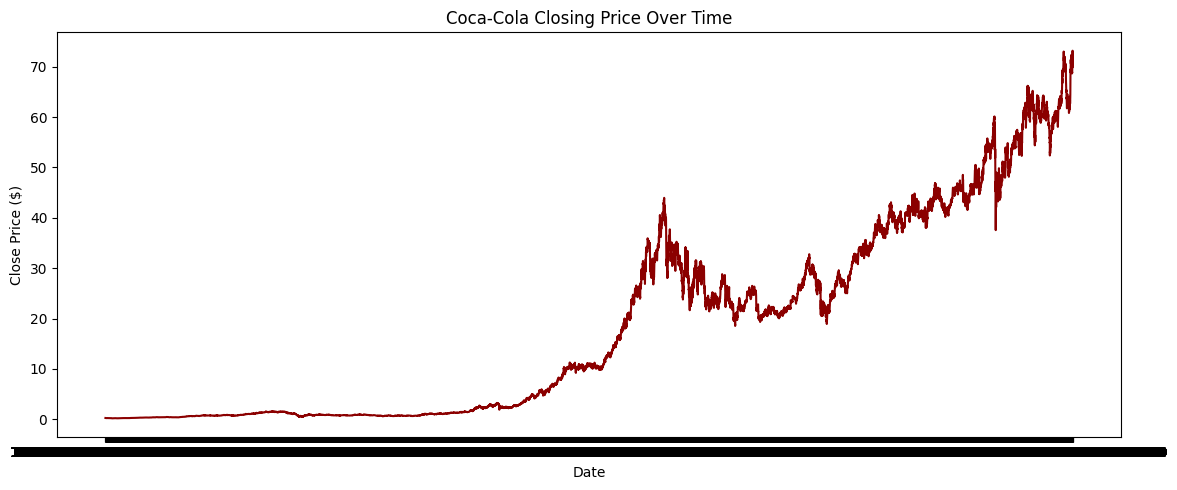

In [12]:
# 1. Close Price Over Time
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['close'], color='darkred')
plt.title('Coca-Cola Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.tight_layout()
plt.show()


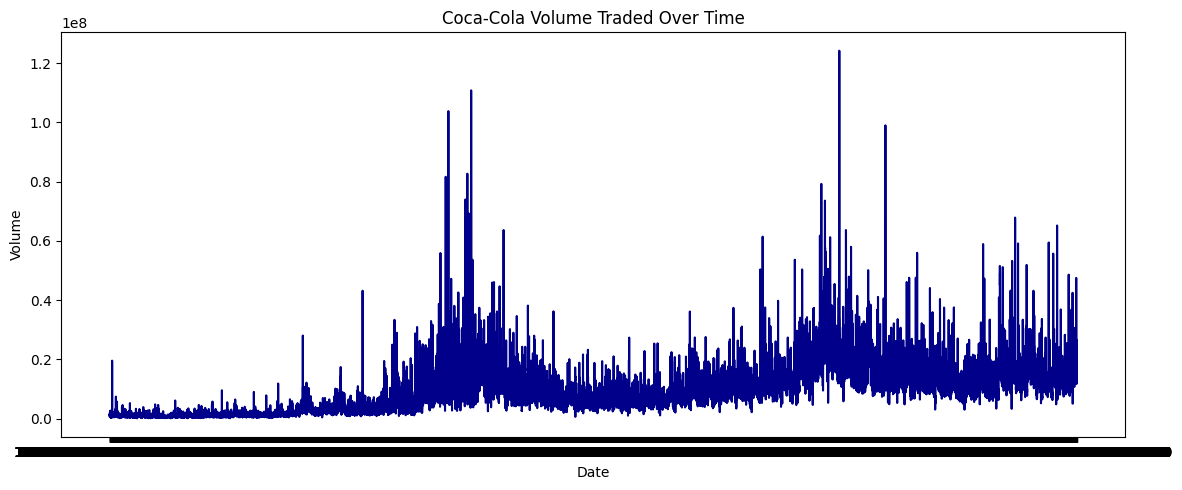

In [13]:
# 2. Volume Traded Over Time
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['volume'], color='darkblue')
plt.title('Coca-Cola Volume Traded Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

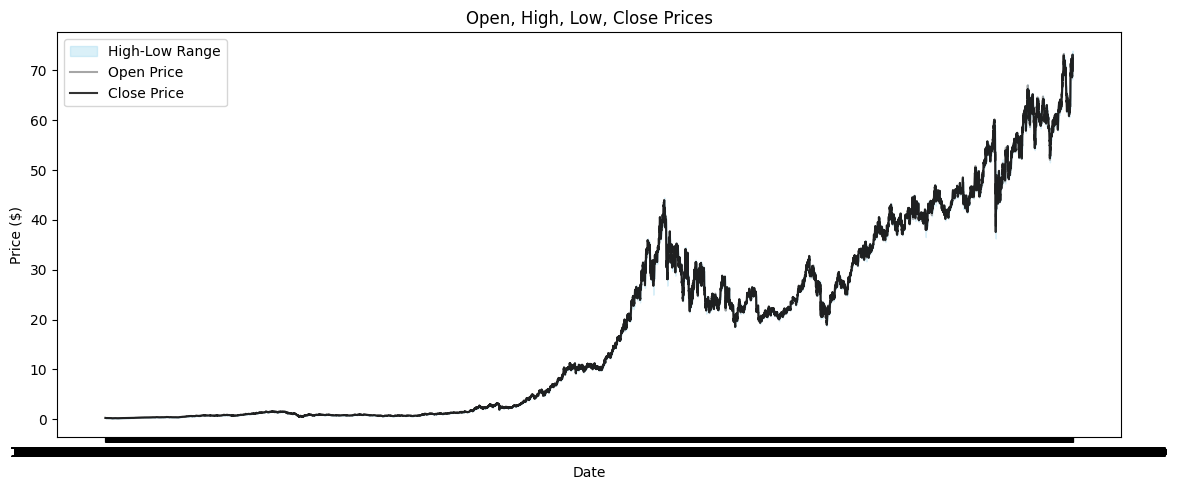

In [14]:
# 3. High vs Low Price (Ribbon Chart)
plt.figure(figsize=(12, 5))
plt.fill_between(df['date'], df['low'], df['high'], color='skyblue', alpha=0.3, label='High-Low Range')
plt.plot(df['date'], df['open'], color='gray', alpha=0.7, label='Open Price')
plt.plot(df['date'], df['close'], color='black', alpha=0.8, label='Close Price')
plt.title('Open, High, Low, Close Prices')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

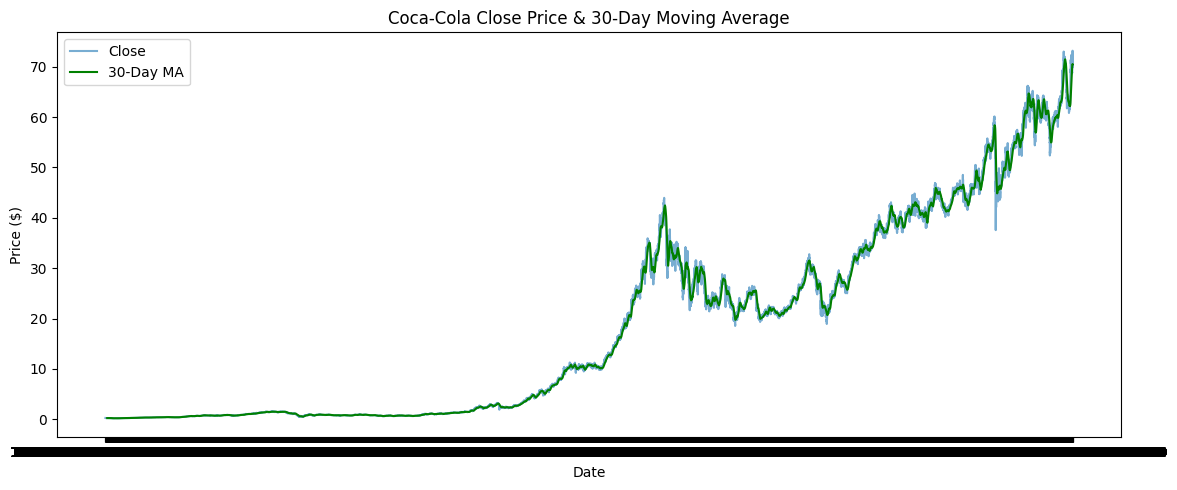

In [15]:
# 4. Moving Average of Close Price
df['ma_30'] = df['close'].rolling(window=30).mean()

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['close'], label='Close', alpha=0.6)
plt.plot(df['date'], df['ma_30'], label='30-Day MA', color='green')
plt.title('Coca-Cola Close Price & 30-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

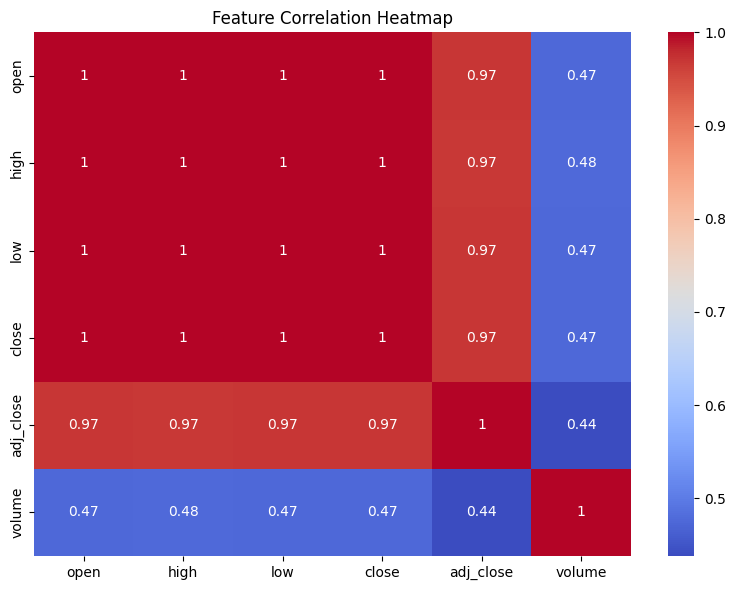

In [16]:
# 5. Heatmap of correlations
plt.figure(figsize=(8, 6))
corr = df[['open', 'high', 'low', 'close', 'adj_close', 'volume']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Predictive Modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score

In [18]:
if df.empty:
    print('The DataFrame is empty. Please check the data source.')
else:
    # Create the target variable for next day close prediction
    df['next_close'] = df['close'].shift(-1)
    df.dropna(inplace=True)

    features = ['open', 'high', 'low', 'volume']
    X = df[features]
    y = df['next_close']

    # Check for sufficient samples
    if X.shape[0] < 10:
        print('Not enough data to perform training and testing.')
    else:
        try:
            # Split data
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

            if X_train.empty:
                raise ValueError("Training set is empty.")

            # Define ML models
            models = {
                "Linear Regression": LinearRegression(),
                "Decision Tree": DecisionTreeRegressor(),
                "Random Forest": RandomForestRegressor(n_estimators=100),
                "Gradient Boosting": GradientBoostingRegressor(),
                "Support Vector Regressor": SVR()
            }

            print("Model Performance (R² Accuracy %):\n")
            for name, model in models.items():
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                r2 = r2_score(y_test, y_pred) * 100  # Convert to percentage
                print(f"{name}: {r2:.2f}%")

        except ValueError as ve:
            print(f"ValueError: {ve}")
        except Exception as e:
            print(f"Unexpected error: {e}")

Model Performance (R² Accuracy %):

Linear Regression: 99.97%
Decision Tree: 99.94%
Random Forest: 99.96%
Gradient Boosting: 99.96%
Support Vector Regressor: 36.26%


## Thank you..pls upvote!!!